# Bear Accelerometer Data — Statistics Analysis

**Dataset**: Bear behavior classification using tri-axial accelerometer (AccX, AccY, AccZ)  
**Data source**: `data/bear/raw/combined.csv`  
**Windowed cache**: `data/bear/data.npy` / `data/bear/label.npy` (auto-generated if missing)

**Label names**:
| ID | Behavior |
|----|----------|
| 0  | unknown  |
| 1  | dig      |
| 2  | eat      |
| 3  | groom    |
| 4  | head_shake |
| 5  | pounce   |
| 6  | rest     |
| 7  | roll     |
| 8  | run      |
| 9  | swim     |
| 10 | walk     |

## 0. Imports & Configuration

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('tab10')

# ── Paths (relative to analysis/bear/) ───────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')
DATA_DIR     = os.path.join(NOTEBOOK_DIR, '..', '..', 'data', 'bear')
CSV_PATH     = os.path.join(DATA_DIR, 'raw', 'combined.csv')
NPY_DATA     = os.path.join(DATA_DIR, 'data.npy')
NPY_LABEL    = os.path.join(DATA_DIR, 'label.npy')
FIG_DIR      = os.path.join(NOTEBOOK_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

LABEL_NAMES = {
    0: 'unknown', 1: 'dig', 2: 'eat', 3: 'groom', 4: 'head_shake',
    5: 'pounce', 6: 'rest', 7: 'roll', 8: 'run', 9: 'swim', 10: 'walk'
}
# Labels after relabeling (csv label - 1): 0-9
LABEL_NAMES_W = {k-1: v for k, v in LABEL_NAMES.items() if k > 0}

AXES        = ['AccX', 'AccY', 'AccZ']
COLORS      = plt.cm.tab10(np.linspace(0, 1, 11))
SAMPLE_RATE = 25   # Hz
WINDOW_SIZE = 50   # timesteps = 2 sec

print('CSV  :', CSV_PATH)
print('npy  :', NPY_DATA)
print('figs :', FIG_DIR)

CSV  : /Users/cassie/Documents/code/DeepView/analysis/bear/../../data/bear/raw/combined.csv
npy  : /Users/cassie/Documents/code/DeepView/analysis/bear/../../data/bear/data.npy
figs : /Users/cassie/Documents/code/DeepView/analysis/bear/figures


## 1. Preprocessing: CSV → Windowed npy

Reproduces the same pipeline as `active_supContrast.py`:
1. Drop `label == 0` (unknown)
2. Relabel `1–10 → 0–9`
3. Z-score normalize AccX/Y/Z (global, same as `gaussian_std` in `analysis/models/utils.py`)
4. Sliding window (size=50, step=50, non-overlapping)
5. Save `data.npy` shape `(N, 3, 50)` and `label.npy` shape `(N, 50)`

In [60]:
def sliding_window(data_np, len_sw, step):
    windows = []
    for idx in range(0, data_np.shape[0] - len_sw - step, step):
        windows.append(data_np[idx: idx + len_sw, :])
    windows.append(data_np[-1 - len_sw: -1, :])  # last window
    return np.stack(windows, axis=0)  # (N, len_sw, n_cols)


def build_windowed_npy(csv_path, npy_data_path, npy_label_path,
                       len_sw=50, step=50):
    print('Reading CSV ...')
    df = pd.read_csv(csv_path)
    print(f'  Raw rows: {len(df):,}')

    df = df[df['label'] != 0].copy()
    df['label_id'] = df['label'].astype(int) - 1   # 1-10 → 0-9
    print(f'  After removing unknown: {len(df):,}')

    # Z-score normalize per axis (gaussian_std)
    acc = df[AXES].values.astype(float)
    mean_v = acc.mean(axis=0)
    std_v  = np.maximum(acc.std(axis=0), 1e-5)
    df[AXES] = (acc - mean_v) / std_v

    selected_np = df[['AccX', 'AccY', 'AccZ', 'label_id']].values  # (N, 4)

    print('Applying sliding window ...')
    windows = sliding_window(selected_np, len_sw, step)  # (W, 50, 4)

    data_b  = np.transpose(windows[:, :, :3], (0, 2, 1))  # (W, 3, 50)
    label_b = windows[:, :, 3]                             # (W, 50)

    np.save(npy_data_path,  data_b)
    np.save(npy_label_path, label_b)
    print(f'Saved data.npy  : {data_b.shape}')
    print(f'Saved label.npy : {label_b.shape}')
    return data_b, label_b


if os.path.exists(NPY_DATA) and os.path.exists(NPY_LABEL):
    print('Loading cached npy files ...')
    X = np.load(NPY_DATA)
    Y = np.load(NPY_LABEL)
else:
    X, Y = build_windowed_npy(CSV_PATH, NPY_DATA, NPY_LABEL,
                               len_sw=WINDOW_SIZE, step=WINDOW_SIZE)

# Per-window label = first timestep label
y = Y[:, 0].astype(int)
labels_to_analyze = sorted(np.unique(y))
class_names       = [LABEL_NAMES_W[l] for l in labels_to_analyze]

print(f'X shape       : {X.shape}  (windows, axes, timesteps)')
print(f'Y shape       : {Y.shape}')
print(f'Unique labels : {labels_to_analyze}')
print(f'Label counts  : {dict(sorted(Counter(y).items()))}')

Loading cached npy files ...
X shape       : (225915, 3, 50)  (windows, axes, timesteps)
Y shape       : (225915, 50)
Unique labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Label counts  : {np.int64(0): 1670, np.int64(1): 5500, np.int64(2): 1480, np.int64(3): 1122, np.int64(4): 148, np.int64(5): 174194, np.int64(6): 2137, np.int64(7): 826, np.int64(8): 1373, np.int64(9): 37465}


In [3]:
# ── Load raw CSV for global statistics ───────────────────────────────────────
print('Reading full CSV for global stats ...')
chunk_list = []
for chunk in pd.read_csv(CSV_PATH, chunksize=1_000_000):
    chunk_list.append(chunk)
df = pd.concat(chunk_list, ignore_index=True)
print(f'Total rows: {len(df):,}')
df.head(3)

Reading full CSV for global stats ...
Total rows: 63,844,805


,AccX,AccY,AccZ,wetdry,individualid,label
0,-9.999999,0.65,3.25,255.0,5.0,0.0
1,-9.950000,0.65,3.20,255.0,5.0,0.0
2,-9.999999,0.65,3.25,255.0,5.0,0.0


In [61]:
# 计算每个class的数据总长度和连续超过50个点的统计
results = []

for label in labels_to_analyze:
    mask = df['label'] == (label + 1)  # 原始CSV中label是1-10
    df_cls = df[mask].copy()
    
    # 总长度（行数）
    total_length = len(df_cls)
    
    # 计算连续超过50个点的段
    y_cls = df_cls['label'].values
    
    # 识别连续段
    continuous_segments = []
    start_idx = 0
    
    for i in range(len(y_cls)):
        if i == len(y_cls) - 1 or y_cls[i] != y_cls[i + 1]:
            segment_length = i - start_idx + 1
            if segment_length >= 50:
                continuous_segments.append(segment_length)
            if i < len(y_cls) - 1:
                start_idx = i + 1
    
    # 统计
    num_segments = len(continuous_segments)
    total_segment_length = sum(continuous_segments)
    avg_segment_length = total_segment_length / num_segments if num_segments > 0 else 0
    
    results.append({
        'label': label,
        'behavior': LABEL_NAMES_W[label],
        'total_length': total_length,
        'num_segments_≥50': num_segments,
        'total_segment_length': total_segment_length,
        'avg_segment_length': round(avg_segment_length, 2),
        'coverage_%': round(total_segment_length / total_length * 100, 2) if total_length > 0 else 0,
    })

result_df = pd.DataFrame(results)
print('=== Per-class Data Length & Continuous Segments (≥50 points) ===')
print(result_df.to_string(index=False))
print()
print(f'Total samples across all classes: {result_df["total_length"].sum():,}')
print(f'Total samples in segments ≥50: {result_df["total_segment_length"].sum():,}')

=== Per-class Data Length & Continuous Segments (≥50 points) ===
 label   behavior  total_length  num_segments_≥50  total_segment_length  avg_segment_length  coverage_%
     0        dig         83456                 1                 83456             83456.0       100.0
     1        eat        274656                 1                274656            274656.0       100.0
     2      groom         74144                 1                 74144             74144.0       100.0
     3 head_shake         55785                 1                 55785             55785.0       100.0
     4     pounce          7120                 1                  7120              7120.0       100.0
     5       rest       8709184                 1               8709184           8709184.0       100.0
     6       roll        106496                 1                106496            106496.0       100.0
     7        run         41120                 1                 41120             41120.0       100.0

In [4]:
print('=== DataFrame info ===')
print(df.dtypes)
print()
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Unique values per column ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique')

=== DataFrame info ===
AccX            float64
AccY            float64
AccZ            float64
wetdry          float64
individualid    float64
label           float64
dtype: object

=== Missing values ===
AccX            0
AccY            0
AccZ            0
wetdry          0
individualid    0
label           0
dtype: int64

=== Unique values per column ===
  AccX: 1025 unique
  AccY: 981 unique
  AccZ: 1015 unique
  wetdry: 3681 unique
  individualid: 5 unique
  label: 11 unique


## 2. Class Distribution

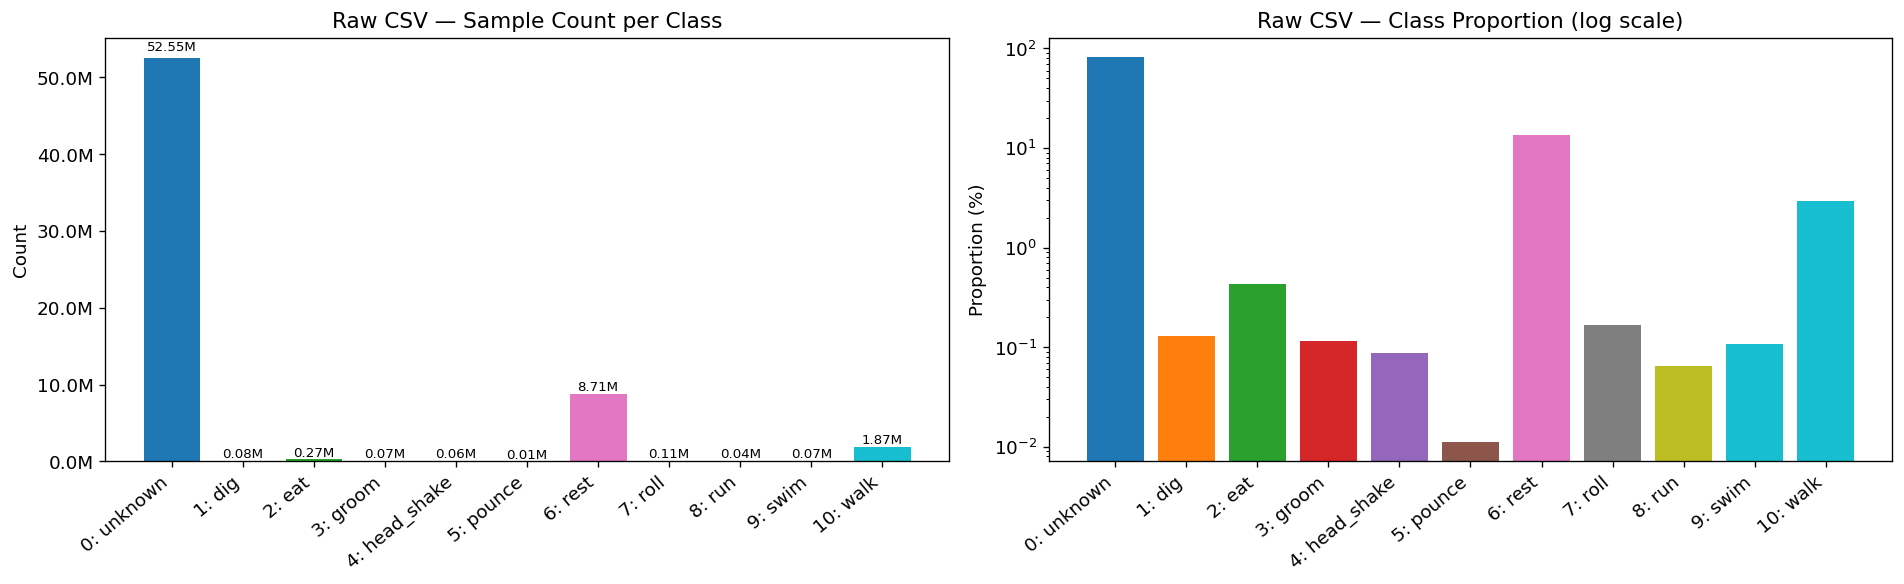

                  Count  Proportion (%)
0: unknown     52549052          82.307
1: dig            83456           0.131
2: eat           274656           0.430
3: groom          74144           0.116
4: head_shake     55785           0.087
5: pounce          7120           0.011
6: rest         8709184          13.641
7: roll          106496           0.167
8: run            41120           0.064
9: swim           68864           0.108
10: walk        1874928           2.937


In [30]:
# ── 2.1 Raw CSV class counts ──────────────────────────────────────────────────
label_counts_raw = df['label'].value_counts().sort_index()
label_counts_raw.index = [f"{int(i)}: {LABEL_NAMES.get(int(i), '?')}" for i in label_counts_raw.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(range(len(label_counts_raw)), label_counts_raw.values, color=COLORS[:len(label_counts_raw)])
ax.set_xticks(range(len(label_counts_raw)))
ax.set_xticklabels(label_counts_raw.index, rotation=40, ha='right')
ax.set_title('Raw CSV — Sample Count per Class')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, v in zip(bars, label_counts_raw.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v/1e6:.2f}M', ha='center', va='bottom', fontsize=8)

ax = axes[1]
proportions = label_counts_raw.values / label_counts_raw.values.sum() * 100
ax.bar(range(len(label_counts_raw)), proportions, color=COLORS[:len(label_counts_raw)])
ax.set_xticks(range(len(label_counts_raw)))
ax.set_xticklabels(label_counts_raw.index, rotation=40, ha='right')
ax.set_yscale('log')
ax.set_title('Raw CSV — Class Proportion (log scale)')
ax.set_ylabel('Proportion (%)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_raw.png'), bbox_inches='tight')
plt.show()

print(pd.DataFrame({'Count': label_counts_raw.values,
                    'Proportion (%)': proportions.round(3)},
                   index=label_counts_raw.index).to_string())

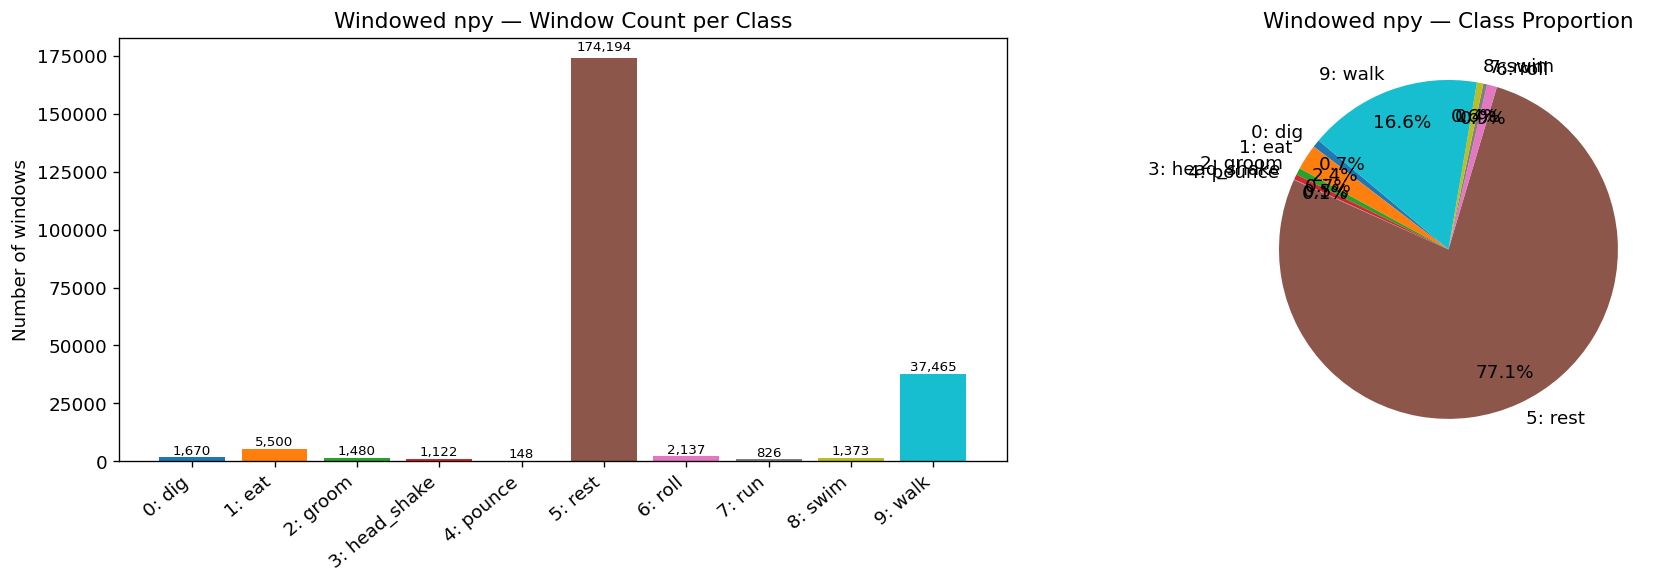

        Class  Count  Proportion (%)
       0: dig   1670            0.74
       1: eat   5500            2.43
     2: groom   1480            0.66
3: head_shake   1122            0.50
    4: pounce    148            0.07
      5: rest 174194           77.11
      6: roll   2137            0.95
       7: run    826            0.37
      8: swim   1373            0.61
      9: walk  37465           16.58


In [6]:
# ── 2.2 Windowed npy class counts ─────────────────────────────────────────────
cnt    = Counter(y)
counts = [cnt[l] for l in labels_to_analyze]
props  = np.array(counts) / sum(counts) * 100
names  = [f"{l}: {LABEL_NAMES_W[l]}" for l in labels_to_analyze]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(range(len(labels_to_analyze)), counts, color=COLORS[:len(labels_to_analyze)])
ax.set_xticks(range(len(labels_to_analyze)))
ax.set_xticklabels(names, rotation=40, ha='right')
ax.set_title('Windowed npy — Window Count per Class')
ax.set_ylabel('Number of windows')
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.pie(props, labels=names, autopct='%1.1f%%', colors=COLORS[:len(labels_to_analyze)],
       startangle=140, pctdistance=0.8)
ax.set_title('Windowed npy — Class Proportion')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_npy.png'), bbox_inches='tight')
plt.show()

print(pd.DataFrame({'Class': names, 'Count': counts,
                    'Proportion (%)': props.round(2)}).to_string(index=False))

In [31]:
# ── 2.3 Class imbalance metrics ───────────────────────────────────────────────
p           = np.array(counts) / sum(counts)
entropy     = -np.sum(p * np.log2(p + 1e-12))
max_entropy = np.log2(len(p))
gini        = 1 - np.sum(p**2)
ir          = max(p) / min(p)
eff_classes = np.exp(entropy)

print('=== Class Imbalance Metrics (windowed npy) ===')
print(f'  Number of behavior classes : {len(p)}')
print(f'  Shannon entropy            : {entropy:.4f}  (max = {max_entropy:.4f})')
print(f'  Normalized entropy         : {entropy/max_entropy:.4f}  (1.0 = perfectly balanced)')
print(f'  Gini impurity              : {gini:.4f}')
print(f'  Imbalance ratio (maj/min)  : {ir:.1f}x')
print(f'  Effective number of classes: {eff_classes:.2f}  (out of {len(p)})')
print()
print('  Recommended class weights (inverse frequency):')
for label_id, pi in zip(labels_to_analyze, p):
    w = (1/pi) / np.sum(1/p)
    print(f'    {label_id:2d} {LABEL_NAMES_W[label_id]:<12} p={pi:.4f}  weight={w:.4f}')

=== Class Imbalance Metrics (windowed npy) ===
  Number of behavior classes : 10
  Shannon entropy            : 1.1323  (max = 3.3219)
  Normalized entropy         : 0.3409  (1.0 = perfectly balanced)
  Gini impurity              : 0.3771
  Imbalance ratio (maj/min)  : 1177.0x
  Effective number of classes: 3.10  (out of 10)

  Recommended class weights (inverse frequency):
     0 dig          p=0.0074  weight=0.0519
     1 eat          p=0.0243  weight=0.0158
     2 groom        p=0.0066  weight=0.0585
     3 head_shake   p=0.0050  weight=0.0772
     4 pounce       p=0.0007  weight=0.5853
     5 rest         p=0.7711  weight=0.0005
     6 roll         p=0.0095  weight=0.0405
     7 run          p=0.0037  weight=0.1049
     8 swim         p=0.0061  weight=0.0631
     9 walk         p=0.1658  weight=0.0023


## 3. Per-Individual (Subject) Analysis

Individuals: [np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


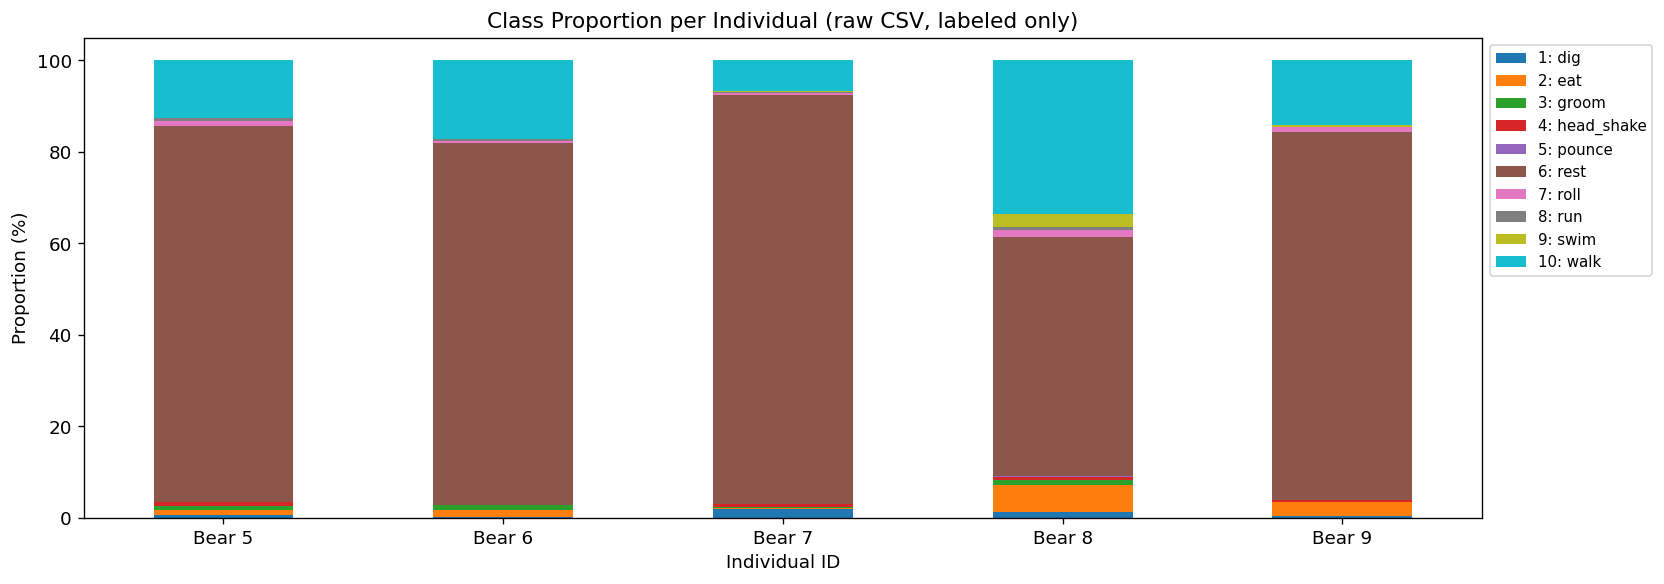


Absolute counts per individual:
              1: dig  2: eat  3: groom  4: head_shake  5: pounce  6: rest  7: roll  8: run  9: swim  10: walk
individualid                                                                                                 
5.0            16896   31104     21824          23154       1504  2249648    26256   16032     1952    344960
6.0             3232   28832     19456           1313        320  1468992     6240    9680        0    318528
7.0            30768    4064      5200           8770          0  1506992     9472     896     4320    113088
8.0            23584  117008     24192          10642       4288  1035792    28480   13232    55312    665728
9.0             8976   93648      3472          11906       1008  2447760    36048    1280     7280    432624


In [32]:
individuals = sorted(df['individualid'].dropna().unique())
print(f'Individuals: {individuals}')

df_labeled = df[df['label'] > 0].copy()
pivot = df_labeled.groupby(['individualid', 'label']).size().unstack(fill_value=0)
pivot.columns = [f"{int(c)}: {LABEL_NAMES.get(int(c), '?')}" for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Class Proportion per Individual (raw CSV, labeled only)')
ax.set_xlabel('Individual ID')
ax.set_ylabel('Proportion (%)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
ax.set_xticklabels([f'Bear {int(i)}' for i in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_dist_per_individual.png'), bbox_inches='tight')
plt.show()

print('\nAbsolute counts per individual:')
print(pivot.to_string())

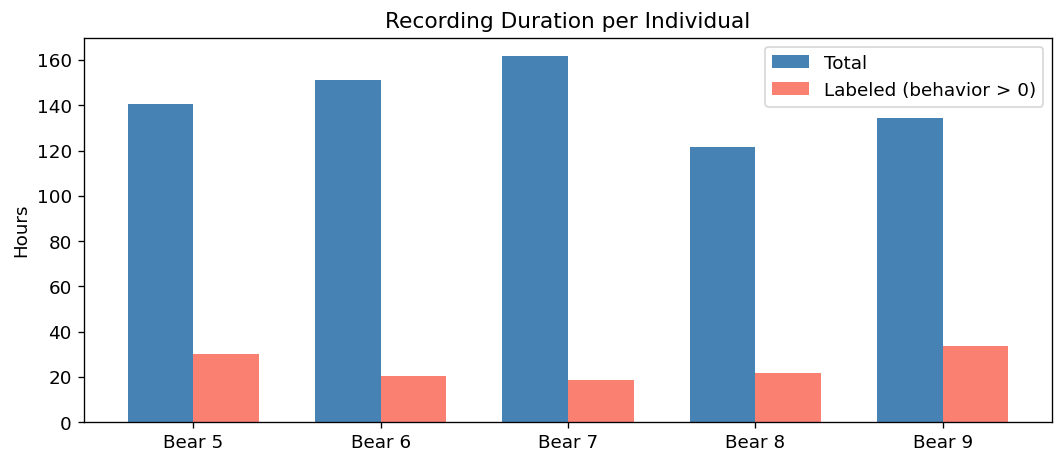

In [33]:
ind_total   = df.groupby('individualid').size()
ind_labeled = df[df['label'] > 0].groupby('individualid').size()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(individuals))
w = 0.35
ax.bar(x - w/2, ind_total.values / SAMPLE_RATE / 3600, w, label='Total', color='steelblue')
ax.bar(x + w/2,
       ind_labeled.reindex(individuals, fill_value=0).values / SAMPLE_RATE / 3600,
       w, label='Labeled (behavior > 0)', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([f'Bear {int(i)}' for i in individuals])
ax.set_ylabel('Hours')
ax.set_title('Recording Duration per Individual')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'recording_duration.png'), bbox_inches='tight')
plt.show()

## 4. Global Value Statistics (Raw CSV)

In [34]:
print('=== Raw accelerometer statistics (all samples) ===')
print(df[AXES].describe().round(4).to_string())
print()
print('Skewness:', df[AXES].skew().round(4).to_dict())
print('Kurtosis:', df[AXES].kurtosis().round(4).to_dict())

=== Raw accelerometer statistics (all samples) ===
               AccX          AccY          AccZ
count  6.384480e+07  6.384480e+07  6.384480e+07
mean  -6.971000e+00 -4.812000e-01 -2.835000e-01
std    4.047200e+00  3.272300e+00  5.642600e+00
min   -2.500000e+01 -2.500000e+01 -2.500000e+01
25%   -9.650000e+00 -2.400000e+00 -4.850000e+00
50%   -7.950000e+00 -4.500000e-01  0.000000e+00
75%   -4.800000e+00  1.500000e+00  3.250000e+00
max    2.625000e+01  2.400000e+01  2.570000e+01

Skewness: {'AccX': 0.8928, 'AccY': -0.1381, 'AccZ': 0.0986}
Kurtosis: {'AccX': 2.5436, 'AccY': 2.8521, 'AccZ': -0.7393}


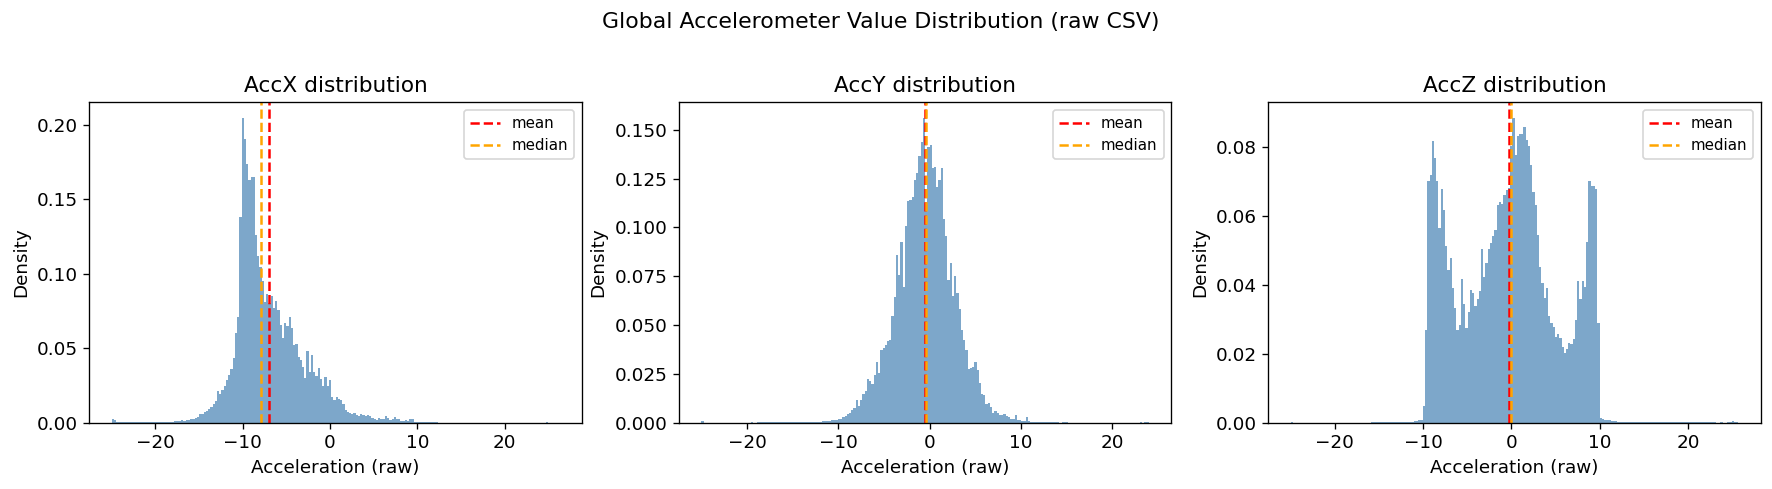

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, AXES):
    ax.hist(df[col].dropna(), bins=200, color='steelblue', alpha=0.7, density=True)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label='median')
    ax.set_title(f'{col} distribution')
    ax.set_xlabel('Acceleration (raw)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.suptitle('Global Accelerometer Value Distribution (raw CSV)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'global_distribution.png'), bbox_inches='tight')
plt.show()

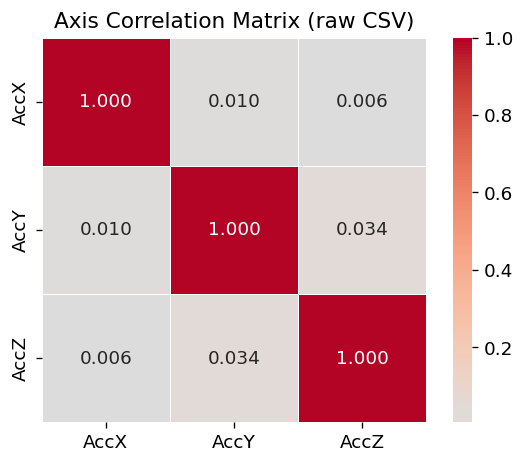

In [36]:
corr = df[AXES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Axis Correlation Matrix (raw CSV)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_correlation.png'), bbox_inches='tight')
plt.show()

## 5. Per-Class Statistics (Windowed npy)

In [37]:
rows = []
for label in labels_to_analyze:
    mask  = y == label
    x_cls = X[mask]  # (N_cls, 3, 50)
    for ai, axis in enumerate(AXES):
        vals = x_cls[:, ai, :].ravel()
        rows.append({
            'label':     label,
            'behavior':  LABEL_NAMES_W[label],
            'axis':      axis,
            'n_windows': int(mask.sum()),
            'mean':      vals.mean(),
            'std':       vals.std(),
            'min':       vals.min(),
            'max':       vals.max(),
            'p25':       np.percentile(vals, 25),
            'p75':       np.percentile(vals, 75),
            'skew':      stats.skew(vals),
            'kurtosis':  stats.kurtosis(vals),
        })

stat_df    = pd.DataFrame(rows)
pivot_stat = stat_df.pivot_table(
    index=['behavior', 'axis'],
    values=['n_windows','mean','std','min','max','p25','p75','skew','kurtosis']
)
print('=== Per-class, per-axis statistics (windowed npy, normalized) ===')
print(pivot_stat.round(3).to_string())

=== Per-class, per-axis statistics (windowed npy, normalized) ===
                 kurtosis    max   mean    min  n_windows    p25    p75   skew    std
behavior   axis                                                                      
dig        AccX     4.571  7.381 -0.202 -4.392     1670.0 -0.671  0.242  0.124  0.837
           AccY     4.775  7.940 -1.534 -7.992     1670.0 -2.225 -0.971  0.580  1.203
           AccZ     5.741  4.176  0.051 -3.935     1670.0 -0.260  0.333  0.648  0.510
eat        AccX     7.241  7.358 -0.334 -4.392     5500.0 -0.706 -0.004  0.497  0.576
           AccY     1.754  7.940 -1.386 -7.992     5500.0 -2.062 -0.824  0.718  0.981
           AccZ     3.113  4.184  0.223 -3.935     5500.0 -0.019  0.477  0.096  0.417
groom      AccX     5.283  7.299 -0.246 -4.392     1480.0 -0.741  0.067  1.572  0.730
           AccY     1.768  7.940 -0.844 -7.992     1480.0 -1.720 -0.156  0.674  1.156
           AccZ     0.292  4.144  0.181 -3.935     1480.0 -0.212  0.589 -0

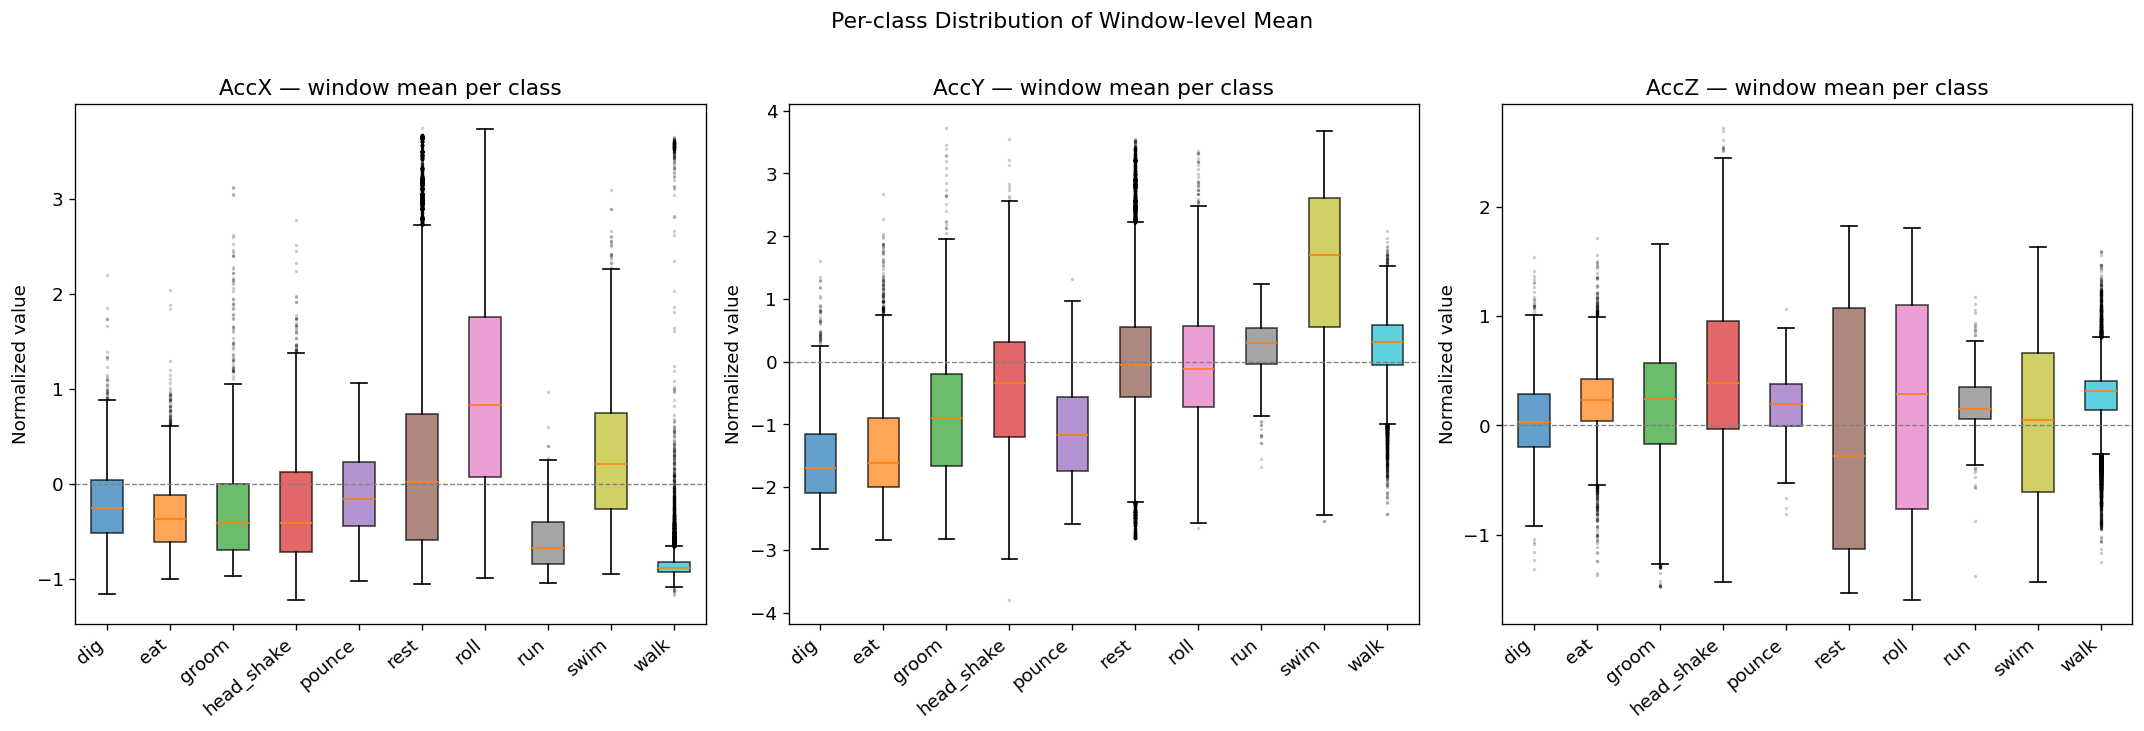

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    data_per_class = [X[y == l, ai, :].mean(axis=1) for l in labels_to_analyze]
    bp = ax.boxplot(data_per_class, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS[:len(labels_to_analyze)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{axis} — window mean per class')
    ax.set_ylabel('Normalized value')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.suptitle('Per-class Distribution of Window-level Mean', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_class_boxplot.png'), bbox_inches='tight')
plt.show()

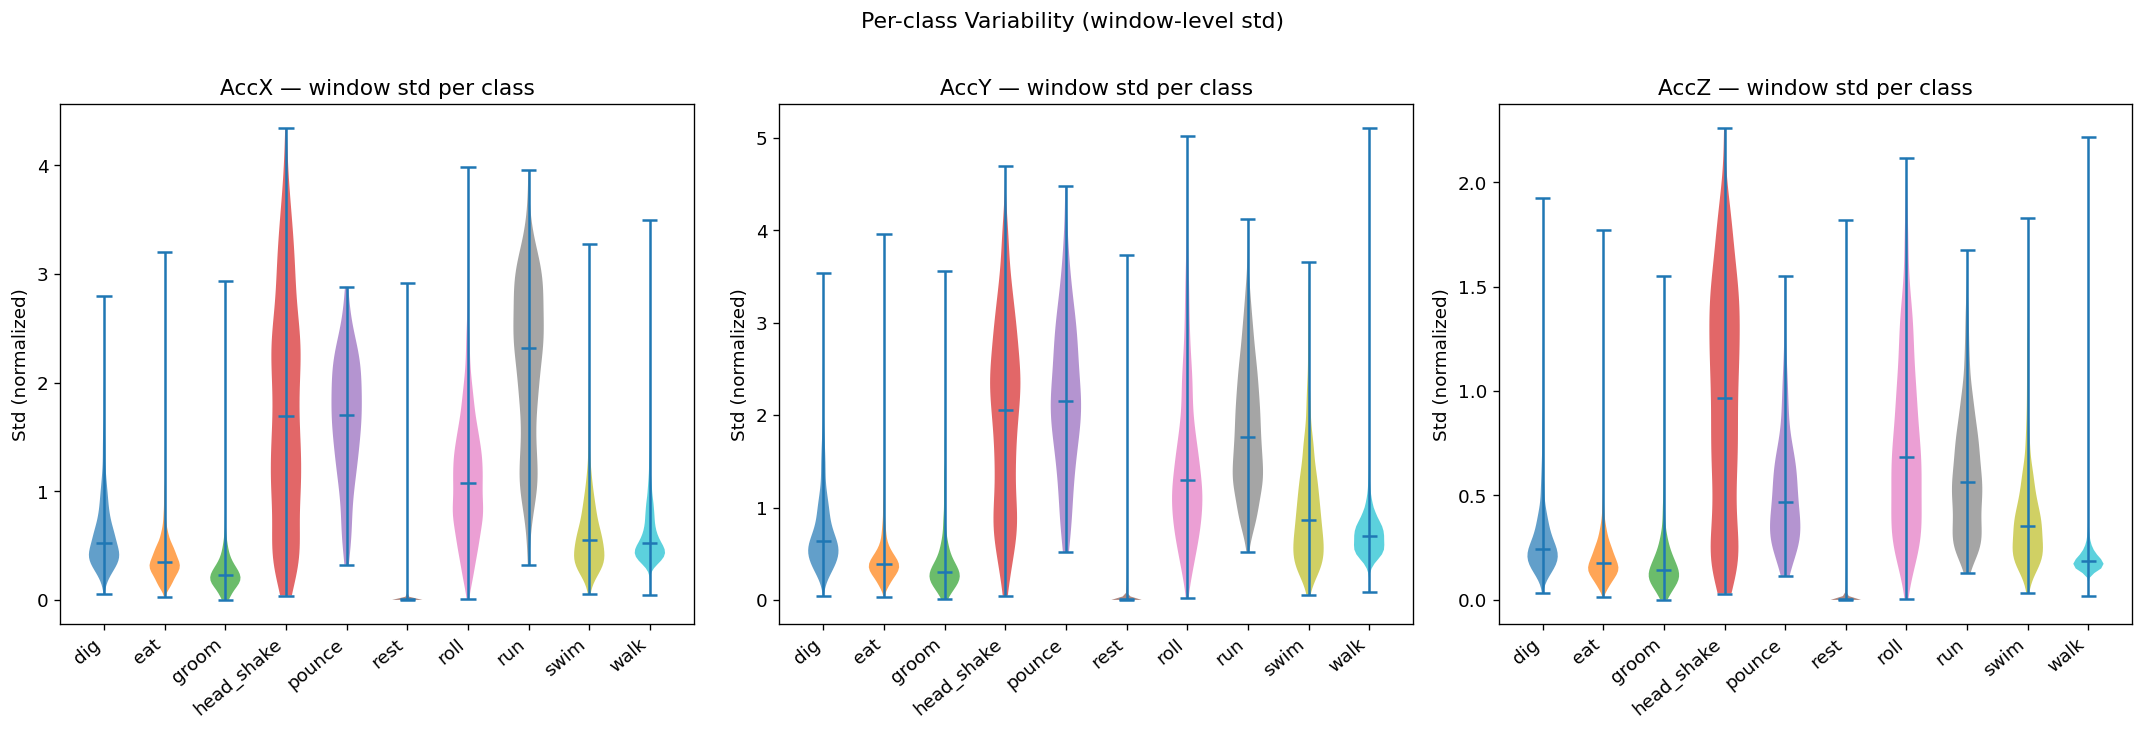

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    data_per_class = [X[y == l, ai, :].std(axis=1) for l in labels_to_analyze]
    parts = ax.violinplot(data_per_class, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS[i])
        pc.set_alpha(0.7)
    ax.set_xticks(range(1, len(class_names)+1))
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_title(f'{axis} — window std per class')
    ax.set_ylabel('Std (normalized)')
plt.suptitle('Per-class Variability (window-level std)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_class_violin_std.png'), bbox_inches='tight')
plt.show()

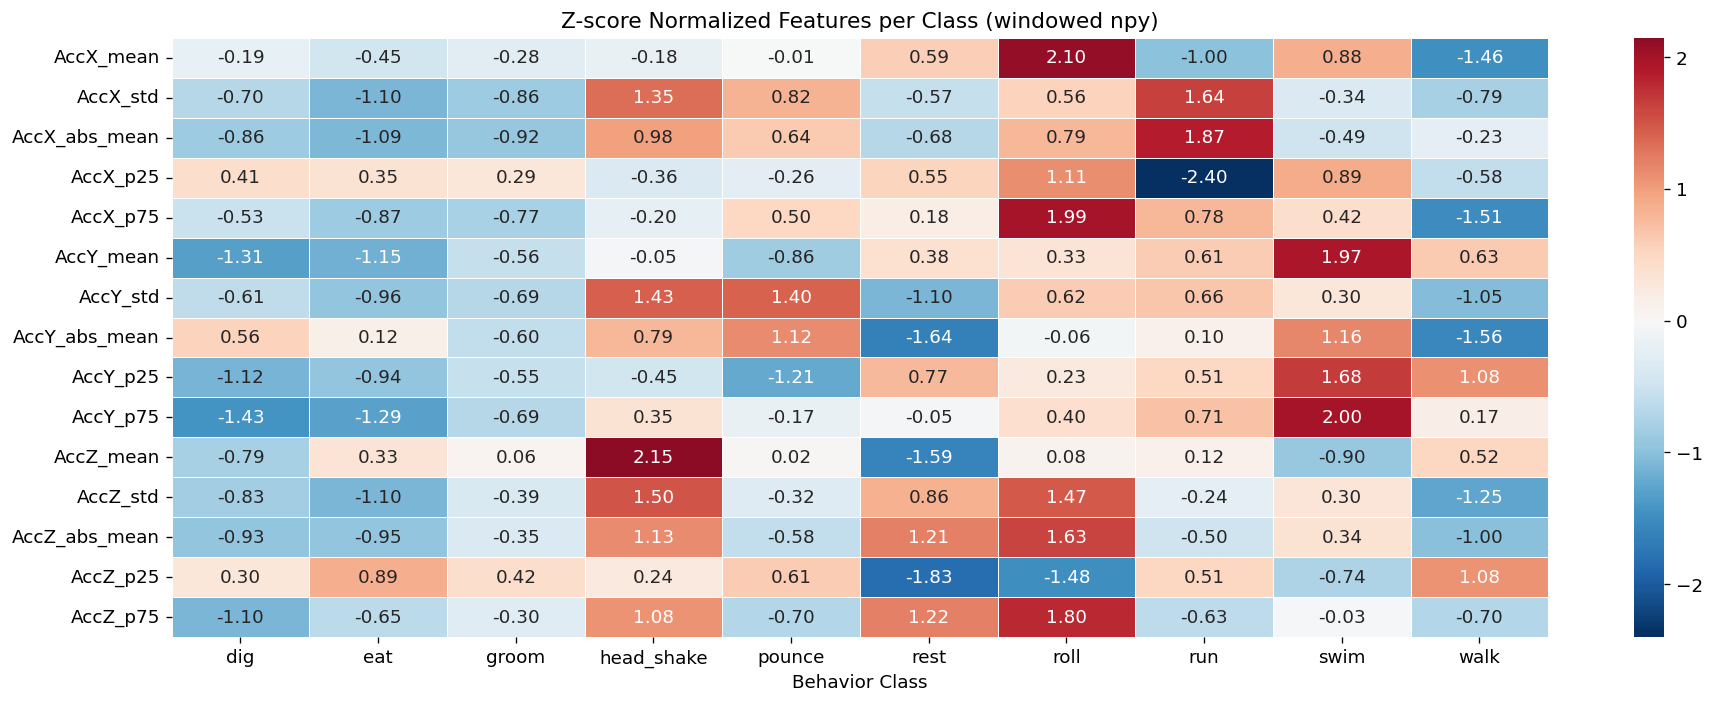

In [40]:
feat_matrix   = []
feature_names = []
for label in labels_to_analyze:
    x_cls = X[y == label]
    row   = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        row += [v.mean(), v.std(), np.abs(v).mean(),
                np.percentile(v, 25), np.percentile(v, 75)]
    feat_matrix.append(row)
for axis in AXES:
    feature_names += [f'{axis}_mean', f'{axis}_std', f'{axis}_abs_mean',
                      f'{axis}_p25', f'{axis}_p75']

feat_df   = pd.DataFrame(feat_matrix, index=class_names, columns=feature_names)
feat_norm = (feat_df - feat_df.mean()) / (feat_df.std() + 1e-8)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(feat_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.3)
ax.set_title('Z-score Normalized Features per Class (windowed npy)')
ax.set_xlabel('Behavior Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_feature_heatmap.png'), bbox_inches='tight')
plt.show()

## 6. Signal Magnitude & Energy Analysis

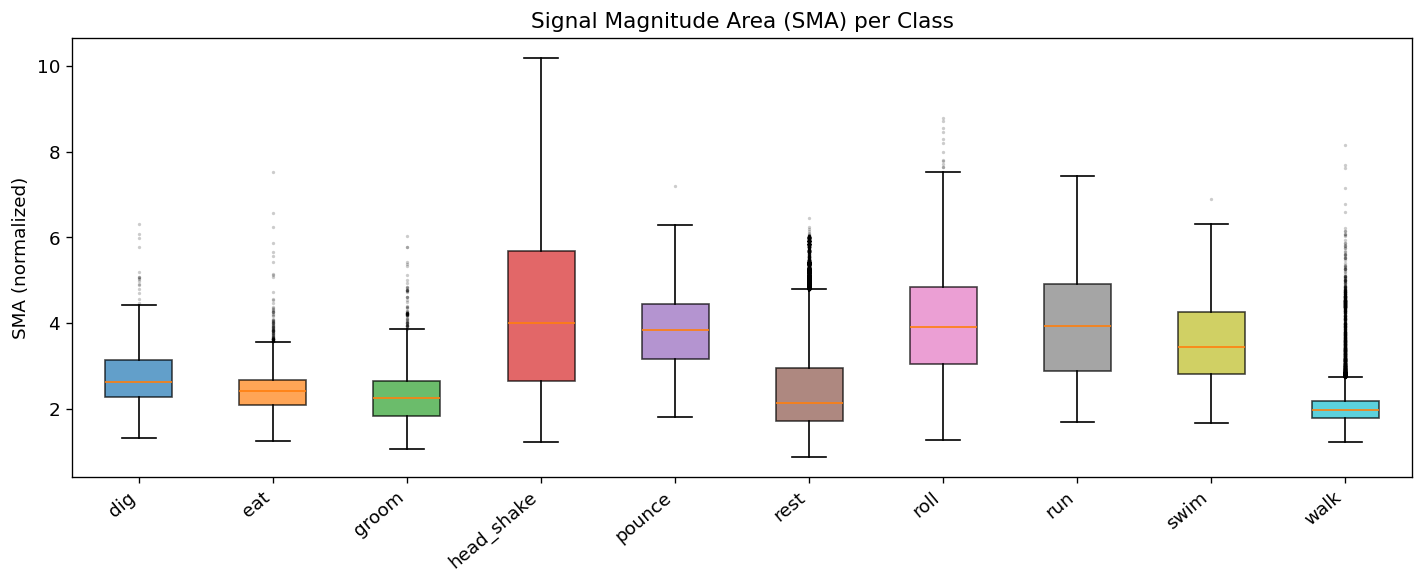

Mean SMA per class:
   0 dig          mean=2.7252  median=2.6254  std=0.6458
   1 eat          mean=2.4087  median=2.4093  std=0.5066
   2 groom        mean=2.3322  median=2.2417  std=0.7241
   3 head_shake   mean=4.3258  median=3.9946  std=1.9627
   4 pounce       mean=3.8189  median=3.8311  std=1.0415
   5 rest         mean=2.4120  median=2.1358  std=0.9262
   6 roll         mean=3.9838  median=3.8991  std=1.2576
   7 run          mean=3.9741  median=3.9273  std=1.2228
   8 swim         mean=3.5518  median=3.4316  std=0.9572
   9 walk         mean=2.0363  median=1.9675  std=0.4212


In [41]:
# SMA = mean(|AccX| + |AccY| + |AccZ|) per window
SMA = np.abs(X).sum(axis=1).mean(axis=1)  # (N,)

fig, ax = plt.subplots(figsize=(12, 5))
sma_by_class = [SMA[y == l] for l in labels_to_analyze]
bp = ax.boxplot(sma_by_class, labels=class_names, patch_artist=True,
                flierprops=dict(marker='.', alpha=0.2, markersize=2))
for patch, color in zip(bp['boxes'], COLORS[:len(labels_to_analyze)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Signal Magnitude Area (SMA) per Class')
ax.set_ylabel('SMA (normalized)')
ax.set_xticklabels(class_names, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sma_per_class.png'), bbox_inches='tight')
plt.show()

print('Mean SMA per class:')
for l, d in zip(labels_to_analyze, sma_by_class):
    print(f'  {l:2d} {LABEL_NAMES_W[l]:<12} mean={d.mean():.4f}  median={np.median(d):.4f}  std={d.std():.4f}')

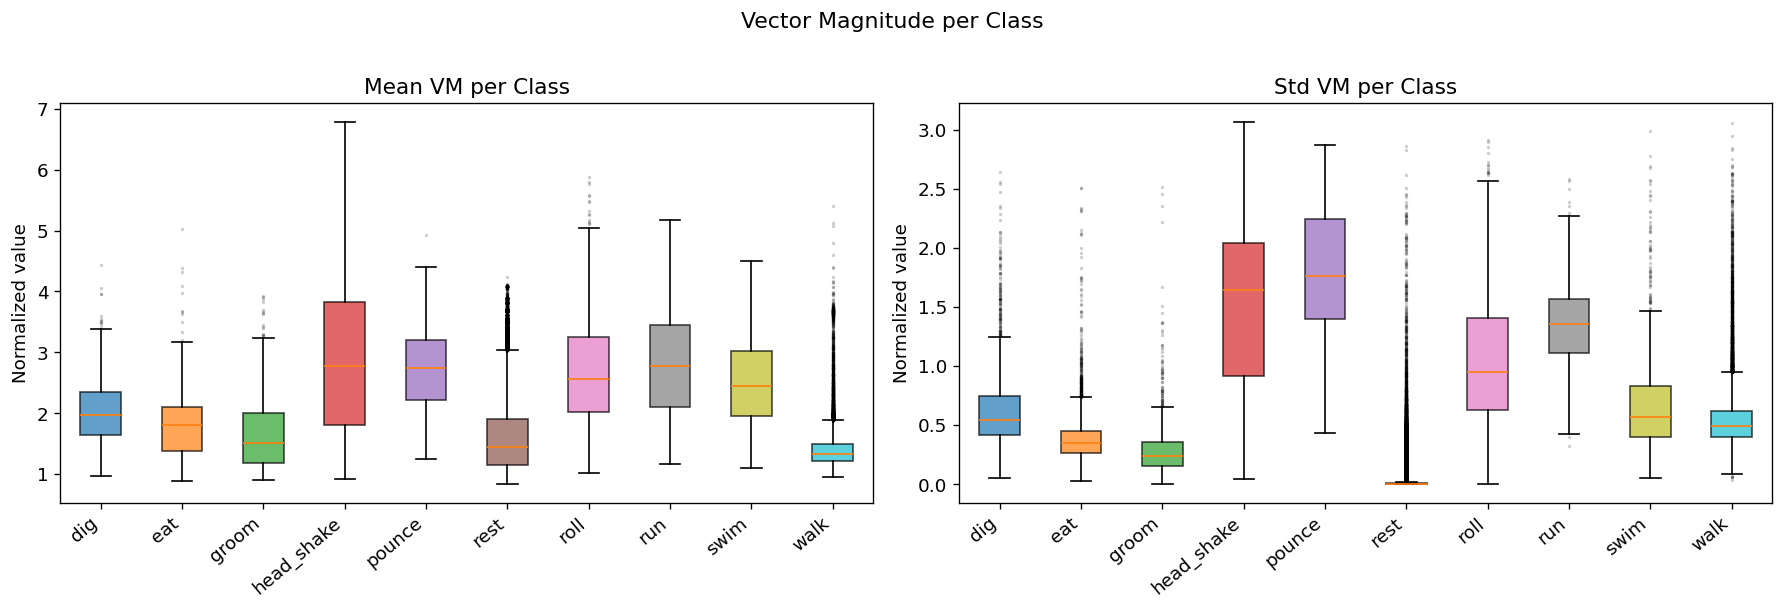

In [42]:
# Vector magnitude VM = sqrt(AccX^2 + AccY^2 + AccZ^2)
VM      = np.sqrt((X**2).sum(axis=1))  # (N, T)
VM_mean = VM.mean(axis=1)
VM_std  = VM.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes, [VM_mean, VM_std], ['Mean VM', 'Std VM']):
    data_cls = [metric[y == l] for l in labels_to_analyze]
    bp = ax.boxplot(data_cls, labels=class_names, patch_artist=True,
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], COLORS[:len(labels_to_analyze)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{title} per Class')
    ax.set_xticklabels(class_names, rotation=40, ha='right')
    ax.set_ylabel('Normalized value')
plt.suptitle('Vector Magnitude per Class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'vector_magnitude.png'), bbox_inches='tight')
plt.show()

## 7. Frequency Domain Analysis

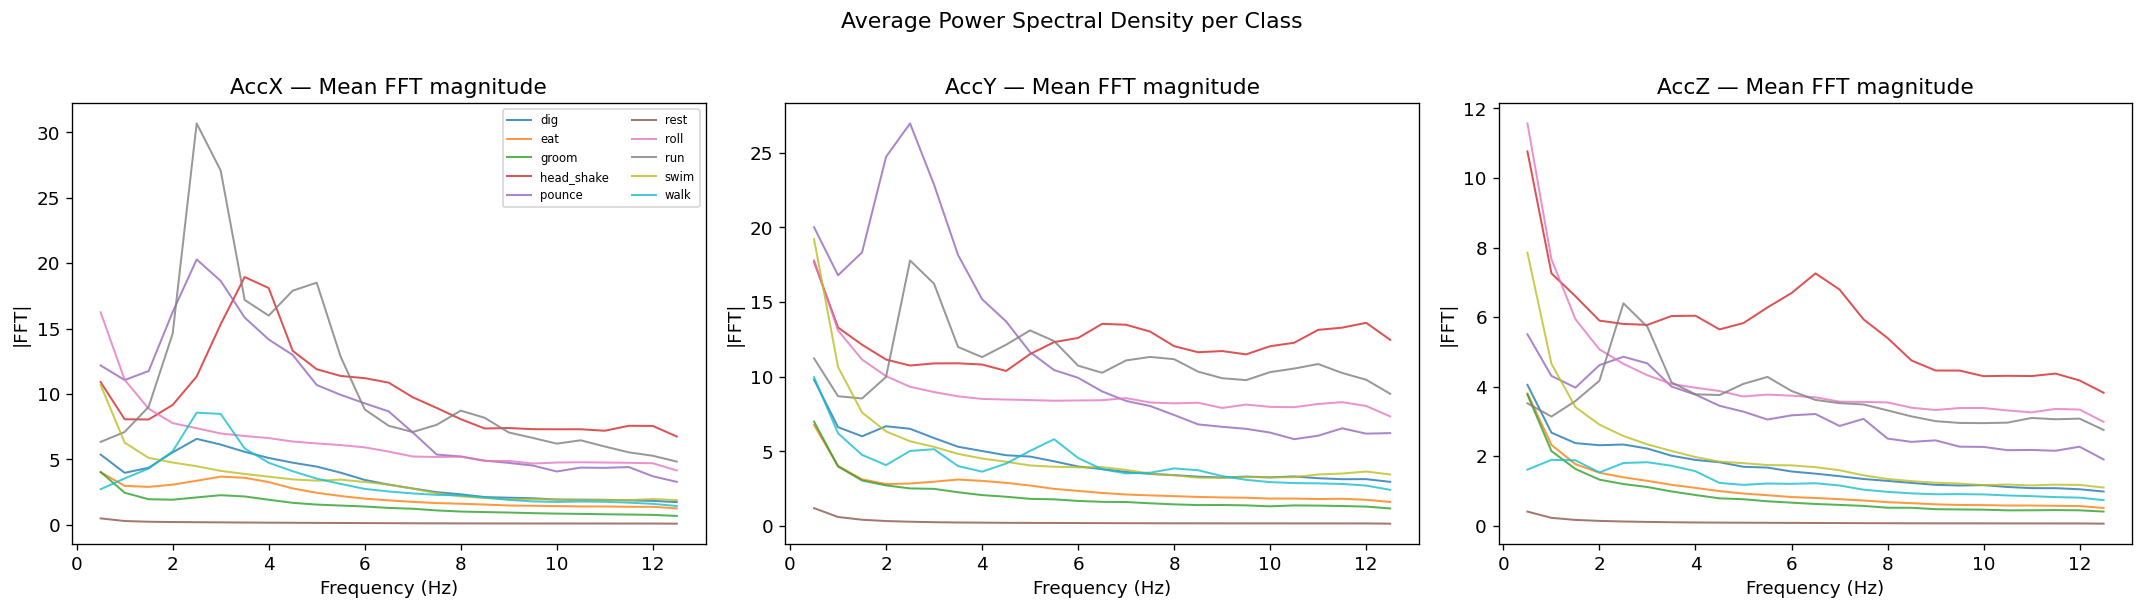

In [43]:
T     = X.shape[2]  # 50
freqs = np.fft.rfftfreq(T, d=1.0/SAMPLE_RATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ai, (ax, axis) in enumerate(zip(axes, AXES)):
    for li, label in enumerate(labels_to_analyze):
        x_cls   = X[y == label, ai, :]
        fft_mag = np.abs(np.fft.rfft(x_cls, axis=1)).mean(axis=0)
        ax.plot(freqs[1:], fft_mag[1:], label=LABEL_NAMES_W[label],
                color=COLORS[li], alpha=0.8, linewidth=1.2)
    ax.set_title(f'{axis} — Mean FFT magnitude')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('|FFT|')
    if ai == 0:
        ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.suptitle('Average Power Spectral Density per Class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'psd_per_class.png'), bbox_inches='tight')
plt.show()

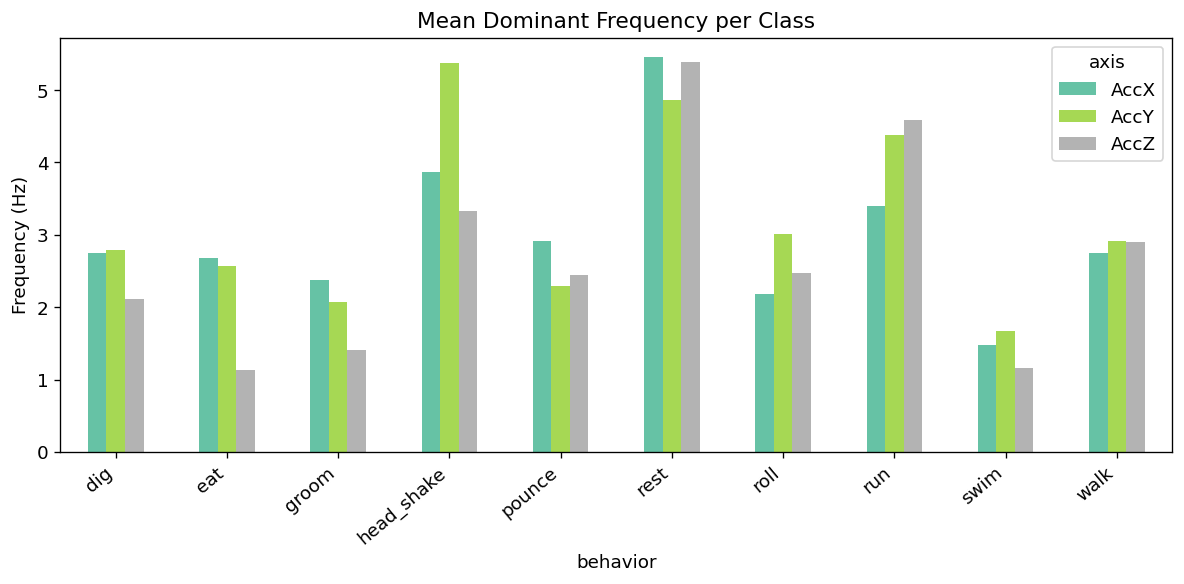

axis         AccX   AccY   AccZ
behavior                       
dig         2.746  2.796  2.106
eat         2.674  2.568  1.127
groom       2.377  2.070  1.407
head_shake  3.873  5.370  3.332
pounce      2.909  2.291  2.443
rest        5.453  4.869  5.391
roll        2.175  3.013  2.472
run         3.403  4.380  4.583
swim        1.478  1.664  1.153
walk        2.753  2.916  2.907


In [44]:
rows_dom = []
for label in labels_to_analyze:
    for ai, axis in enumerate(AXES):
        x_cls    = X[y == label, ai, :]
        fft_mag  = np.abs(np.fft.rfft(x_cls, axis=1))[:, 1:]
        dom_freq = freqs[1:][fft_mag.argmax(axis=1)]
        rows_dom.append({'behavior': LABEL_NAMES_W[label], 'axis': axis,
                         'mean_dom_freq': dom_freq.mean(),
                         'std_dom_freq':  dom_freq.std()})

pivot_dom = pd.DataFrame(rows_dom).pivot(
    index='behavior', columns='axis', values='mean_dom_freq')

fig, ax = plt.subplots(figsize=(10, 5))
pivot_dom.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Mean Dominant Frequency per Class')
ax.set_ylabel('Frequency (Hz)')
ax.set_xticklabels(pivot_dom.index, rotation=40, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dominant_freq.png'), bbox_inches='tight')
plt.show()
print(pivot_dom.round(3).to_string())

## 8. Average Window Shape per Class

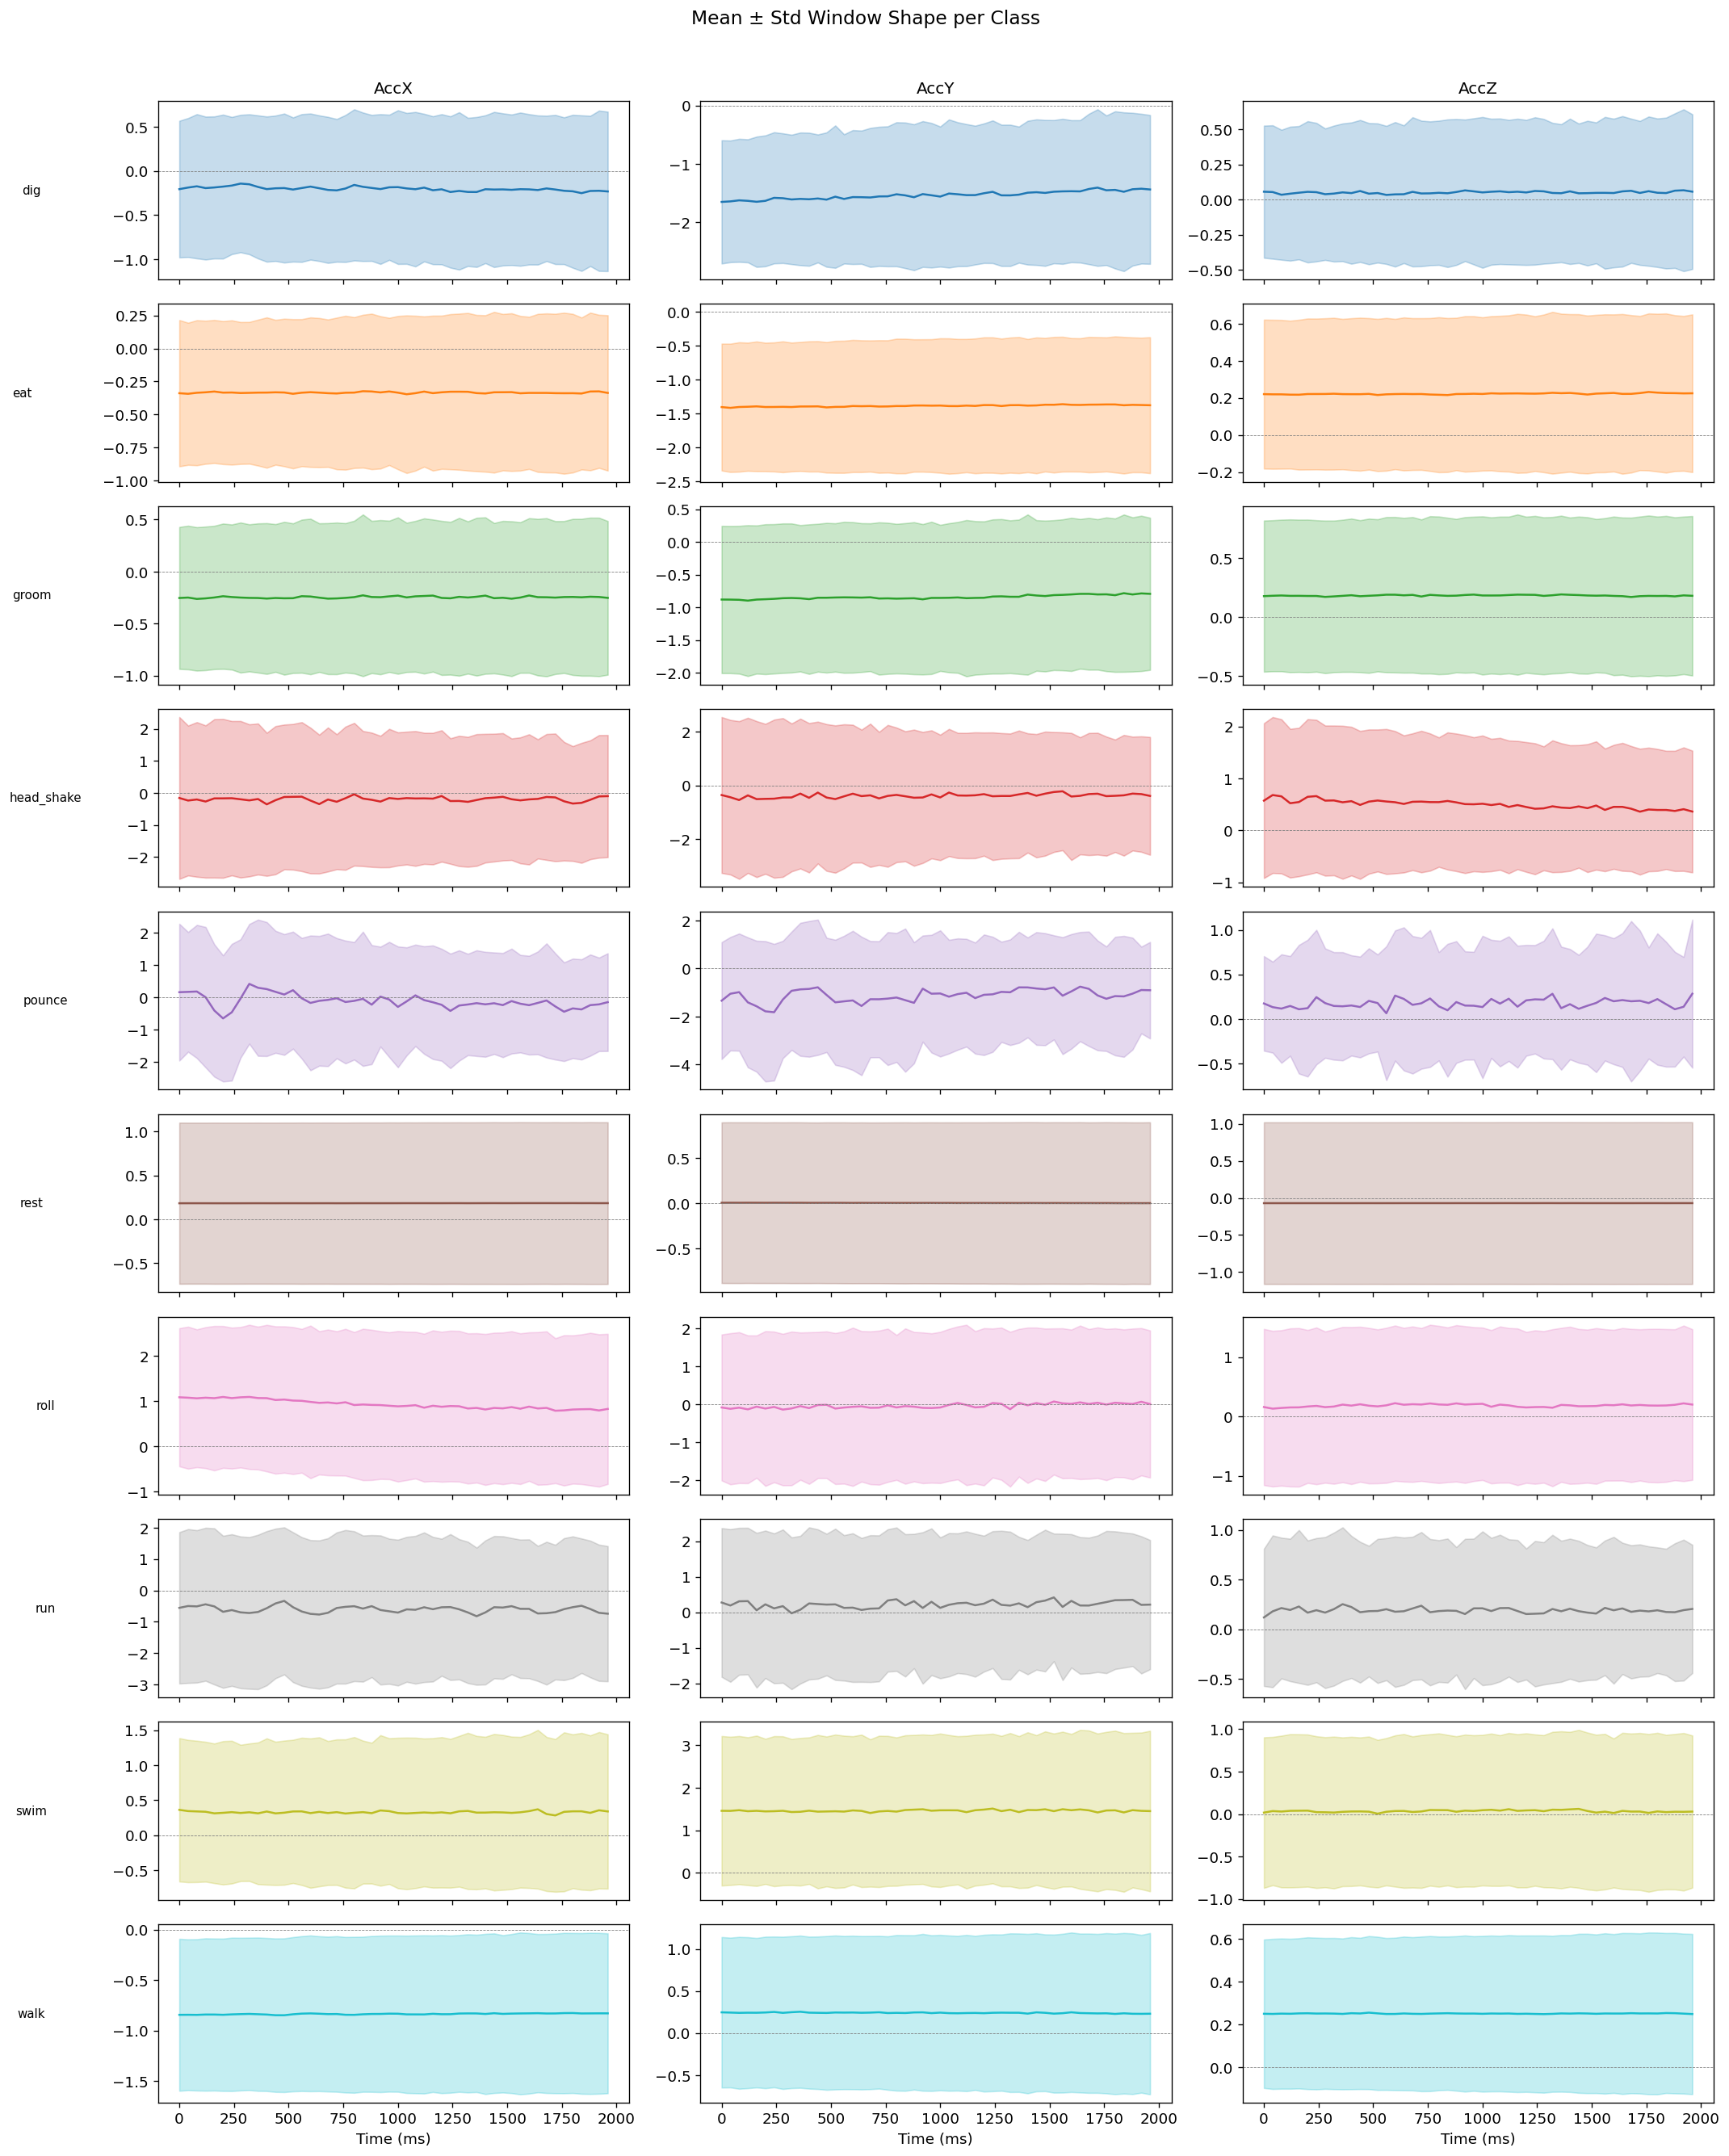

In [45]:
n_cls = len(labels_to_analyze)
fig, axes = plt.subplots(n_cls, 3, figsize=(18, 2.2 * n_cls), sharex=True)
t = np.arange(T) / SAMPLE_RATE * 1000  # ms

for row, label in enumerate(labels_to_analyze):
    x_cls = X[y == label]  # (N_cls, 3, T)
    for ai, axis in enumerate(AXES):
        ax = axes[row, ai]
        mu = x_cls[:, ai, :].mean(axis=0)
        sd = x_cls[:, ai, :].std(axis=0)
        ax.plot(t, mu, color=COLORS[row], linewidth=1.5)
        ax.fill_between(t, mu - sd, mu + sd, alpha=0.25, color=COLORS[row])
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        if row == 0:
            ax.set_title(axis, fontsize=12)
        if ai == 0:
            ax.set_ylabel(LABEL_NAMES_W[label], fontsize=9,
                          rotation=0, labelpad=60, va='center')
        if row == n_cls - 1:
            ax.set_xlabel('Time (ms)')

plt.suptitle('Mean ± Std Window Shape per Class', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'avg_window_per_class.png'), bbox_inches='tight')
plt.show()

## 9. Between-Class Separability

In [46]:
print('=== Kruskal-Wallis H-test (classes, per axis) ===')
for ai, axis in enumerate(AXES):
    groups = [X[y == l, ai, :].ravel() for l in labels_to_analyze]
    h, pv  = kruskal(*groups)
    print(f'  {axis}: H = {h:.2f}, p = {pv:.2e}  → {"SIGNIFICANT" if pv < 0.05 else "not significant"}')

=== Kruskal-Wallis H-test (classes, per axis) ===
  AccX: H = 2003178.80, p = 0.00e+00  → SIGNIFICANT
  AccY: H = 798031.88, p = 0.00e+00  → SIGNIFICANT
  AccZ: H = 233335.70, p = 0.00e+00  → SIGNIFICANT


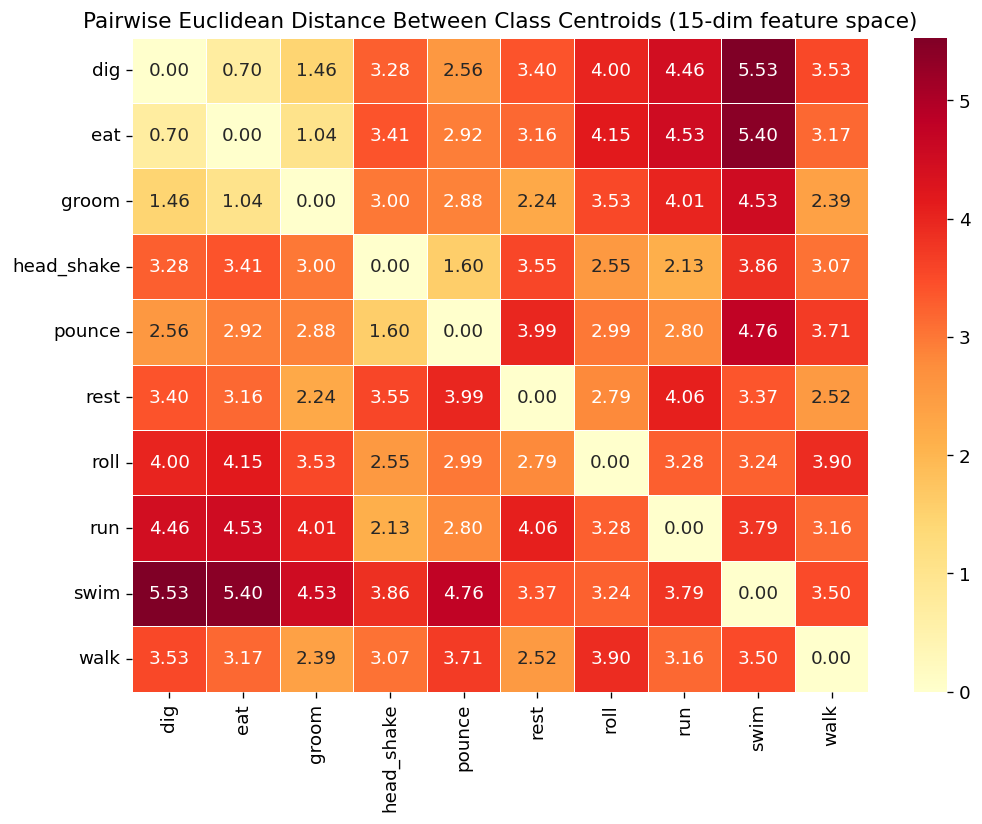

In [47]:
def class_centroid(x_cls):
    feats = []
    for ai in range(3):
        v = x_cls[:, ai, :]
        feats += [v.mean(axis=1).mean(), v.std(axis=1).mean(),
                  np.percentile(v, 25), np.percentile(v, 75), np.abs(v).mean()]
    return np.array(feats)

centroids = np.array([class_centroid(X[y == l]) for l in labels_to_analyze])
dist_mat  = pairwise_distances(centroids)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(dist_mat, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.3)
ax.set_title('Pairwise Euclidean Distance Between Class Centroids (15-dim feature space)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pairwise_class_distance.png'), bbox_inches='tight')
plt.show()

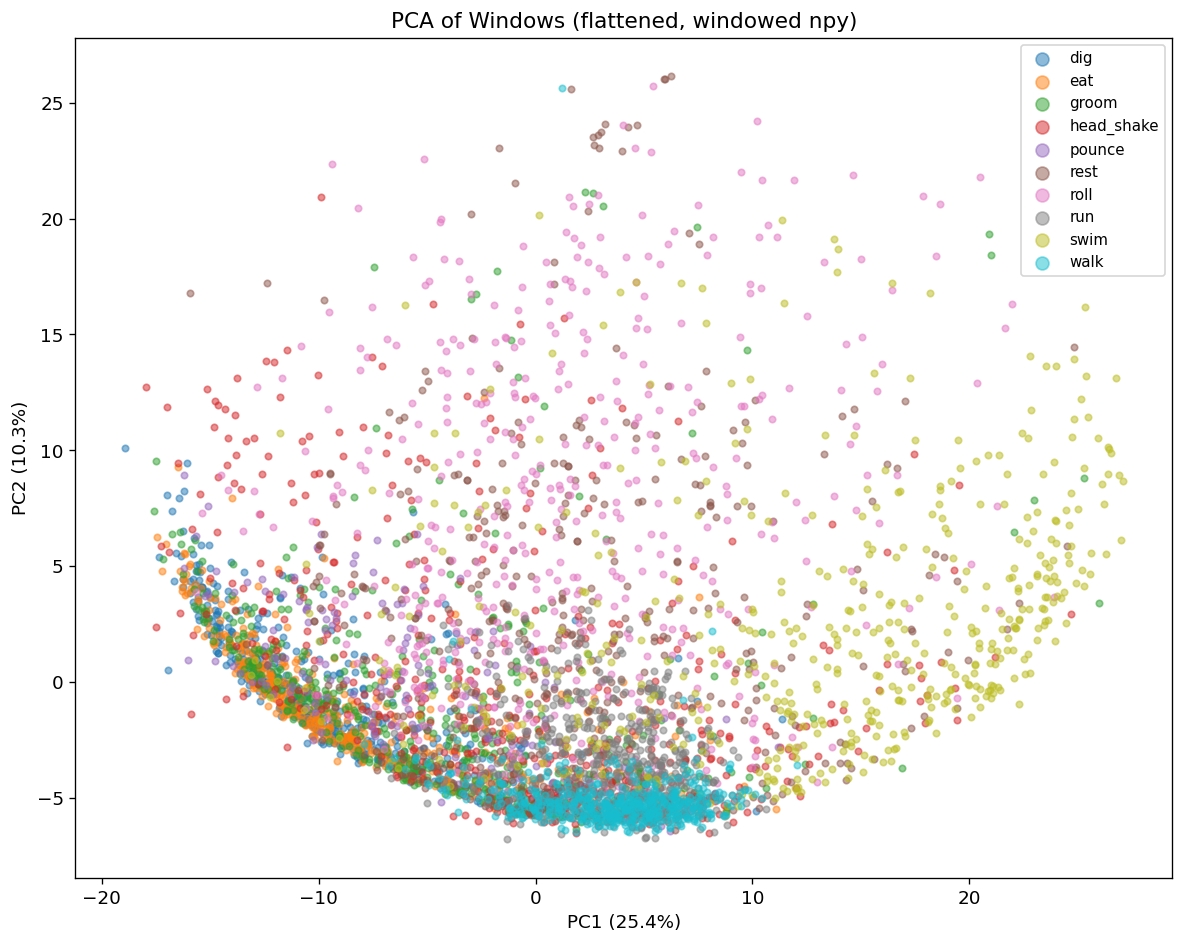

Total variance explained by PC1+PC2: 35.7%


In [48]:
# PCA visualization (sub-sampled per class)
N_PER_CLASS = 500
idx_all = []
for label in labels_to_analyze:
    idx_l  = np.where(y == label)[0]
    n_take = min(N_PER_CLASS, len(idx_l))
    idx_all.append(np.random.choice(idx_l, n_take, replace=False))
idx_all = np.concatenate(idx_all)

X_flat  = X[idx_all].reshape(len(idx_all), -1)  # (N_sub, 150)
y_sub   = y[idx_all]

pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(10, 8))
for li, label in enumerate(labels_to_analyze):
    mask = y_sub == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[COLORS[li]], label=LABEL_NAMES_W[label], alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Windows (flattened, windowed npy)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pca_visualization.png'), bbox_inches='tight')
plt.show()
print(f'Total variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%')

## 10. Axis Cross-Correlation per Class

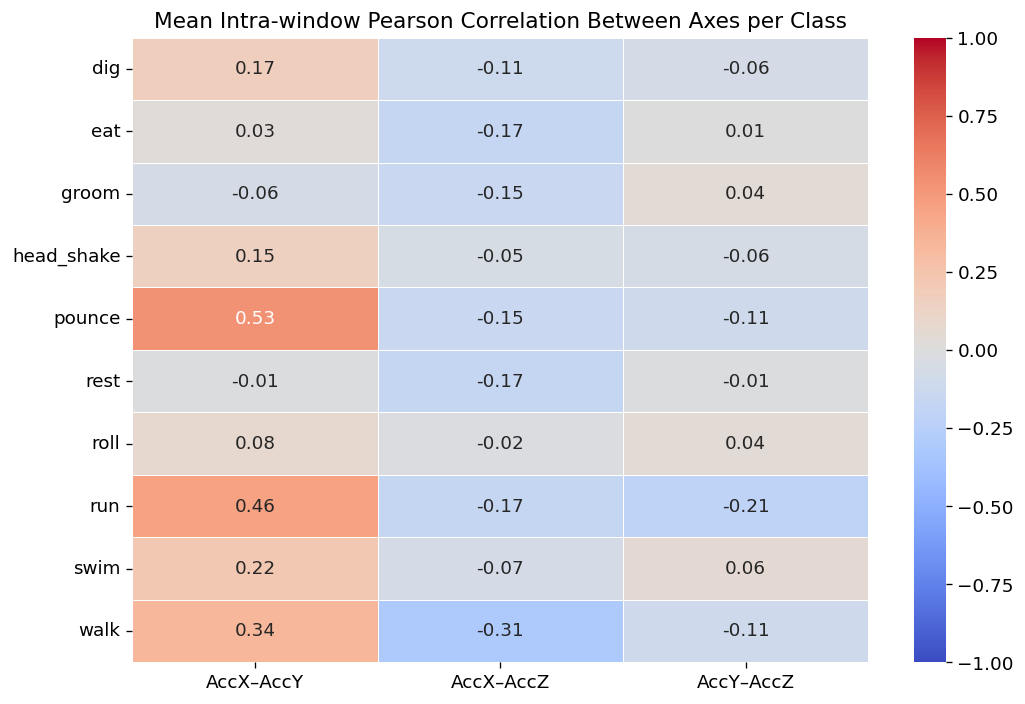

In [49]:
axis_pairs = [('AccX','AccY',0,1), ('AccX','AccZ',0,2), ('AccY','AccZ',1,2)]
corr_data  = {f'{a}\u2013{b}': [] for a, b, _, __ in axis_pairs}

for label in labels_to_analyze:
    x_cls = X[y == label]
    for a_name, b_name, ai, bi in axis_pairs:
        r_vals = [np.corrcoef(x_cls[n, ai], x_cls[n, bi])[0, 1] for n in range(len(x_cls))]
        corr_data[f'{a_name}\u2013{b_name}'].append(np.nanmean(r_vals))

corr_df = pd.DataFrame(corr_data, index=class_names)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Mean Intra-window Pearson Correlation Between Axes per Class')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'axis_xcorr_per_class.png'), bbox_inches='tight')
plt.show()

## 11. Window Quality & Label Consistency

In [50]:
y_all    = Y.astype(int)
all_same = (y_all == y_all[:, [0]]).all(axis=1)
print(f'Windows with 100% consistent labels : {all_same.sum():,} / {len(all_same):,} ({all_same.mean()*100:.1f}%)')
print(f'Windows with mixed labels           : {(~all_same).sum():,} ({(~all_same).mean()*100:.1f}%)')
print()
print(f'Window size : {T} timesteps = {T/SAMPLE_RATE*1000:.0f} ms at {SAMPLE_RATE} Hz')
print(f'Total windows : {len(X):,}')
for ai, axis in enumerate(AXES):
    v = X[:, ai, :]
    print(f'{axis}: global min={v.min():.4f}  max={v.max():.4f}  mean={v.mean():.6f}  std={v.std():.6f}')

Windows with 100% consistent labels : 221,141 / 225,915 (97.9%)
Windows with mixed labels           : 4,774 (2.1%)

Window size : 50 timesteps = 2000 ms at 25 Hz
Total windows : 225,915
AccX: global min=-4.3924  max=7.5917  mean=-0.000000  std=1.000000
AccY: global min=-7.9916  max=7.9722  mean=-0.000000  std=1.000000
AccZ: global min=-3.9349  max=4.1844  mean=0.000000  std=1.000000


## 12. Wetdry Sensor Analysis

=== Wetdry sensor statistics ===
count    6.384480e+07
mean     2.509724e+02
std      1.978400e+01
min      2.500000e+01
25%      2.550000e+02
50%      2.550000e+02
75%      2.550000e+02
max      2.550000e+02


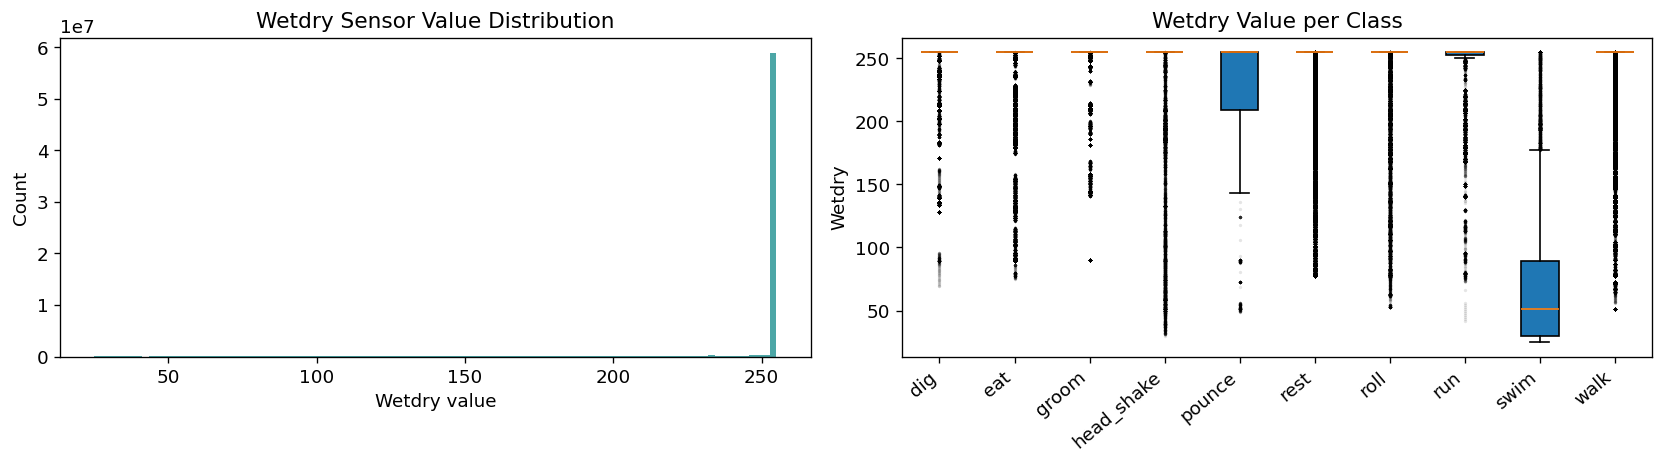

In [51]:
print('=== Wetdry sensor statistics ===')
print(df['wetdry'].describe().round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df['wetdry'].dropna(), bins=100, color='teal', alpha=0.7)
ax.set_title('Wetdry Sensor Value Distribution')
ax.set_xlabel('Wetdry value')
ax.set_ylabel('Count')

ax = axes[1]
df_labeled2 = df[df['label'] > 0]
cls_names2  = [LABEL_NAMES[l] for l in sorted(LABEL_NAMES)
               if l > 0 and l in df_labeled2['label'].values]
wetdry_cls  = [df_labeled2[df_labeled2['label'] == l]['wetdry'].dropna().values
               for l in sorted(LABEL_NAMES) if l > 0 and l in df_labeled2['label'].values]
ax.boxplot(wetdry_cls, labels=cls_names2, patch_artist=True,
           flierprops=dict(marker='.', alpha=0.1, markersize=2))
ax.set_title('Wetdry Value per Class')
ax.set_xticklabels(cls_names2, rotation=40, ha='right')
ax.set_ylabel('Wetdry')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wetdry_analysis.png'), bbox_inches='tight')
plt.show()

## 13. Summary Table for Model Training

In [52]:
summary_rows = []
for label, pi in zip(labels_to_analyze, p):
    mask    = y == label
    x_cls   = X[mask]
    sma_val = np.abs(x_cls).sum(axis=1).mean(axis=1).mean()
    vm_val  = np.sqrt((x_cls**2).sum(axis=1)).mean(axis=1).mean()
    row = {
        'label':           label,
        'behavior':        LABEL_NAMES_W[label],
        'n_windows':       int(mask.sum()),
        'prop_%':          round(pi * 100, 2),
        'inv_freq_weight': round((1/pi) / sum(1/q for q in p), 4),
        'SMA_mean':        round(float(sma_val), 4),
        'VM_mean':         round(float(vm_val), 4),
    }
    for ai, axis in enumerate(AXES):
        v = x_cls[:, ai, :]
        row[f'{axis}_mean'] = round(float(v.mean()), 4)
        row[f'{axis}_std']  = round(float(v.std()),  4)
        row[f'{axis}_min']  = round(float(v.min()),  4)
        row[f'{axis}_max']  = round(float(v.max()),  4)
    summary_rows.append(row)

summary_all = pd.DataFrame(summary_rows).set_index('label')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print('=== Summary for Model Training ===')
print(summary_all.to_string())

=== Summary for Model Training ===
         behavior  n_windows  prop_%  inv_freq_weight  SMA_mean  VM_mean  AccX_mean  AccX_std  AccX_min  AccX_max  AccY_mean  AccY_std  AccY_min  AccY_max  AccZ_mean  AccZ_std  AccZ_min  AccZ_max
label                                                                                                                                                                                              
0             dig       1670    0.74           0.0519    2.7252   2.0014    -0.2018    0.8371   -4.3924    7.3811    -1.5336    1.2034   -7.9916    7.9397     0.0514    0.5104   -3.9349    4.1764
1             eat       5500    2.43           0.0158    2.4087   1.7747    -0.3342    0.5759   -4.3924    7.3577    -1.3861    0.9807   -7.9916    7.9397     0.2227    0.4165   -3.9349    4.1844
2           groom       1480    0.66           0.0585    2.3322   1.6359    -0.2464    0.7299   -4.3924    7.2992    -0.8439    1.1559   -7.9916    7.9397     0.1810    0.6596   -3.

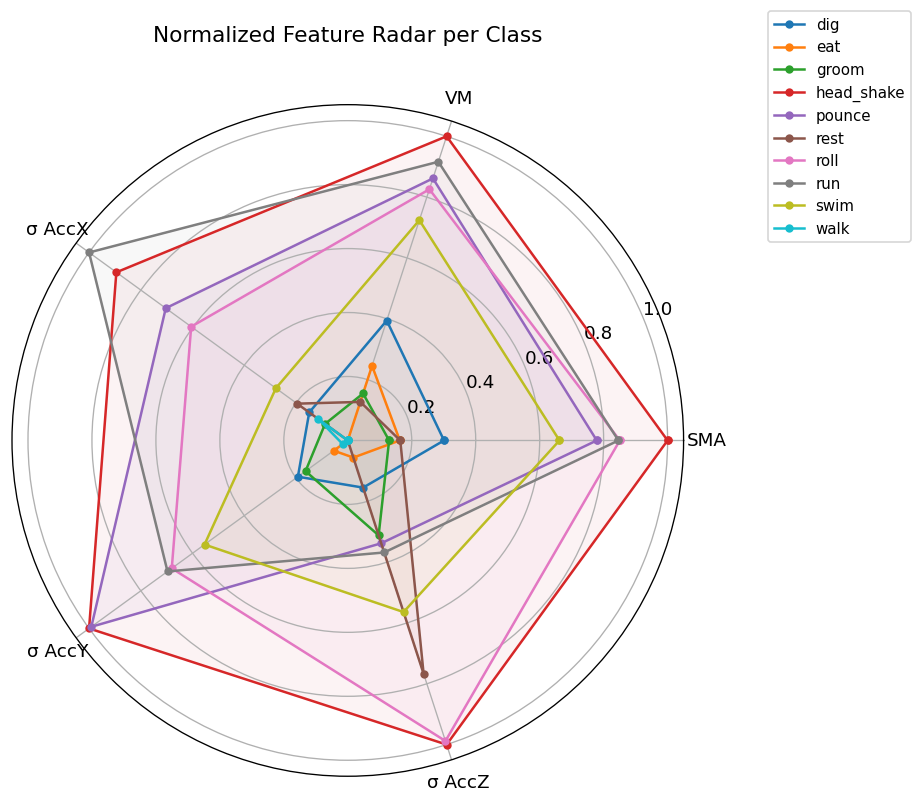

In [53]:
metrics       = ['SMA_mean', 'VM_mean', 'AccX_std', 'AccY_std', 'AccZ_std']
metric_labels = ['SMA', 'VM', '\u03c3 AccX', '\u03c3 AccY', '\u03c3 AccZ']

vals      = summary_all[metrics].values
vals_norm = (vals - vals.min(axis=0)) / (vals.max(axis=0) - vals.min(axis=0) + 1e-8)

K      = len(metrics)
angles = np.linspace(0, 2 * np.pi, K, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for li, (label, row) in enumerate(zip(labels_to_analyze, vals_norm)):
    values = row.tolist() + row[:1].tolist()
    ax.plot(angles, values, 'o-', linewidth=1.5,
            color=COLORS[li], label=LABEL_NAMES_W[label], markersize=4)
    ax.fill(angles, values, alpha=0.05, color=COLORS[li])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_title('Normalized Feature Radar per Class', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'radar_chart.png'), bbox_inches='tight')
plt.show()

## 14. Key Observations & Recommendations

| Item | Value |
|------|-------|
| CSV path | `data/bear/raw/combined.csv` |
| Windowed npy | `data/bear/data.npy` / `label.npy` |
| Number of behavior classes (npy) | 10 (relabeled 0–9) |
| Window size | 50 timesteps = 2 sec @ 25 Hz |
| Input tensor shape | (3, 50) per sample |
| Normalization | Z-score per axis (global, same as `gaussian_std`) |
| Class imbalance | Severe — check normalized entropy above |
| Recommended handling | Inverse-frequency class weights (see Section 2.3) |
| Cross-subject variability | Check Section 3 individual plots |